# RQ3: Model Comparison

**Research question:** How do traditional machine learning models compare with neural network models in predicting short-form video trend labels?

## 1. Setup

In [1]:
# Import traditional and neural-network classifiers for the model comparison.
import warnings

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import ParameterGrid
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TARGET = "trend_label"

pd.set_option("display.max_columns", 100)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


## 2. Load Processed Data

The inputs are already numeric because preprocessing handled categorical encoding. RQ3 uses the full encoded feature matrix for every model so that the comparison isolates model choice rather than feature-group choice.

In [2]:
# Load the shared processed splits used across RQ notebooks.
train = pd.read_csv("../data/processed/train.csv")
validation = pd.read_csv("../data/processed/validation.csv")
test = pd.read_csv("../data/processed/test.csv")

X_train = train.drop(columns=TARGET)
y_train = train[TARGET]

X_val = validation.drop(columns=TARGET)
y_val = validation[TARGET]

X_test = test.drop(columns=TARGET)
y_test = test[TARGET]

# Output: split shapes, numeric-feature check, and training class balance.
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
print("Non-numeric columns:", X_train.select_dtypes(exclude=["number"]).columns.tolist())

display(y_train.value_counts(normalize=True).sort_index())

Train: (33655, 203) (33655,)
Validation: (7212, 203) (7212,)
Test: (7212, 203) (7212,)
Non-numeric columns: []


trend_label
declining    0.249651
rising       0.251701
seasonal     0.252622
stable       0.246026
Name: proportion, dtype: float64

## 3. Model Set and Hyperparameter Tuning

Feature groups are not varied in this notebook. RQ2 already evaluates feature-group effectiveness, while RQ3 focuses on whether model family changes predictive performance.

The model set covers a high-bias to lower-bias range: a majority baseline, linear models, a single decision tree, an ensemble tree model, and an MLP neural network. Each model has at least one hyperparameter tuned using validation macro F1.


In [3]:
# Define model builders and compact hyperparameter grids for validation tuning.
def format_params(params):
    return ", ".join(f"{key}={value}" for key, value in params.items())


model_configs = {
    "Dummy Majority": {
        "type": "baseline",
        "bias_variance_position": "highest bias / lowest variance reference model",
        "tuned_hyperparameters": "strategy",
        "param_grid": {
            "strategy": ["most_frequent", "prior"],
        },
        "build_model": lambda params: DummyClassifier(
            strategy=params["strategy"],
            random_state=RANDOM_STATE,
        ),
    },
    "Logistic Regression": {
        "type": "traditional",
        "bias_variance_position": "high-bias linear classifier",
        "tuned_hyperparameters": "C",
        "param_grid": {
            "C": [0.1, 1.0, 10.0],
        },
        "build_model": lambda params: make_pipeline(
            StandardScaler(),
            LogisticRegression(
                C=params["C"],
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    },
    "Linear SVM": {
        "type": "traditional",
        "bias_variance_position": "regularised linear margin classifier",
        "tuned_hyperparameters": "C",
        "param_grid": {
            "C": [0.1, 1.0, 10.0],
        },
        "build_model": lambda params: make_pipeline(
            StandardScaler(),
            LinearSVC(
                C=params["C"],
                class_weight="balanced",
                max_iter=5000,
                random_state=RANDOM_STATE,
            ),
        ),
    },
    "Decision Tree": {
        "type": "traditional",
        "bias_variance_position": "low-bias / high-variance single tree",
        "tuned_hyperparameters": "max_depth, min_samples_leaf",
        "param_grid": {
            "max_depth": [6, 12],
            "min_samples_leaf": [5, 20],
        },
        "build_model": lambda params: DecisionTreeClassifier(
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    },
    "Random Forest": {
        "type": "traditional",
        "bias_variance_position": "lower-variance ensemble of decision trees",
        "tuned_hyperparameters": "n_estimators, min_samples_leaf",
        "param_grid": {
            "n_estimators": [80, 120],
            "min_samples_leaf": [5, 10],
        },
        "build_model": lambda params: RandomForestClassifier(
            n_estimators=params["n_estimators"],
            min_samples_leaf=params["min_samples_leaf"],
            class_weight="balanced_subsample",
            n_jobs=1,
            random_state=RANDOM_STATE,
        ),
    },
    "MLP Neural Network": {
        "type": "neural_network",
        "bias_variance_position": "flexible non-linear neural model",
        "tuned_hyperparameters": "hidden_layer_sizes, alpha",
        "param_grid": {
            "hidden_layer_sizes": [(32,), (64, 32)],
            "alpha": [0.0001, 0.001],
        },
        "build_model": lambda params: make_pipeline(
            StandardScaler(),
            MLPClassifier(
                hidden_layer_sizes=params["hidden_layer_sizes"],
                alpha=params["alpha"],
                max_iter=80,
                random_state=RANDOM_STATE,
            ),
        ),
    },
}

# Display the planned search so the tuning choices are explicit.
hyperparameter_plan = pd.DataFrame([
    {
        "model": model_name,
        "type": config["type"],
        "bias_variance_position": config["bias_variance_position"],
        "tuned_hyperparameters": config["tuned_hyperparameters"],
        "candidate_values": config["param_grid"],
    }
    for model_name, config in model_configs.items()
])

# Output: model types, bias/variance role, and hyperparameter search space.
display(hyperparameter_plan)


,model,type,bias_variance_position,tuned_hyperparameters,candidate_values
0,Dummy Majority,baseline,highest bias / lowest variance reference model,strategy,"{'strategy': ['most_frequent', 'prior']}"
1,Logistic Regression,traditional,high-bias linear classifier,C,"{'C': [0.1, 1.0, 10.0]}"
2,Linear SVM,traditional,regularised linear margin classifier,C,"{'C': [0.1, 1.0, 10.0]}"
3,Decision Tree,traditional,low-bias / high-variance single tree,"max_depth, min_samples_leaf","{'max_depth': [6, 12], 'min_samples_leaf': [5,..."
4,Random Forest,traditional,lower-variance ensemble of decision trees,"n_estimators, min_samples_leaf","{'n_estimators': [80, 120], 'min_samples_leaf'..."
5,MLP Neural Network,neural_network,flexible non-linear neural model,"hidden_layer_sizes, alpha","{'hidden_layer_sizes': [(32,), (64, 32)], 'alp..."


## 4. Validation Comparison

All models use the same stratified train/validation/test split created in preprocessing. This is suitable here because the dataset is large enough for a hold-out validation set, and stratification keeps the four trend classes similarly balanced across splits.

Hyperparameters are selected using validation macro F1 because this is a multi-class task and each class should contribute equally to model selection. The test set is kept separate until after tuning.


In [4]:
# Run validation tuning and keep the best fitted version of each model family.
tuning_rows = []
validation_rows = []
trained_models = {}
chosen_params = {}

# Tune each model independently using validation macro F1.
for model_name, config in model_configs.items():
    best = None

    for params in ParameterGrid(config["param_grid"]):
        model = config["build_model"](params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        accuracy = accuracy_score(y_val, y_pred)
        macro_f1 = f1_score(y_val, y_pred, average="macro")

        # Store validation accuracy and macro F1 for every candidate setting.
        tuning_rows.append({
            "model": model_name,
            "type": config["type"],
            "hyperparameters": format_params(params),
            "accuracy": accuracy,
            "macro_f1": macro_f1,
        })

        if best is None or macro_f1 > best["macro_f1"]:
            best = {
                "params": params,
                "model": model,
                "accuracy": accuracy,
                "macro_f1": macro_f1,
            }

    # Store the already-fitted best model for final test evaluation.
    trained_models[model_name] = best["model"]
    chosen_params[model_name] = best["params"]

    validation_rows.append({
        "model": model_name,
        "type": config["type"],
        "bias_variance_position": config["bias_variance_position"],
        "tuned_hyperparameters": config["tuned_hyperparameters"],
        "chosen_hyperparameters": format_params(best["params"]),
        "accuracy": best["accuracy"],
        "macro_f1": best["macro_f1"],
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["model", "macro_f1"],
    ascending=[True, False],
).reset_index(drop=True)

validation_results = pd.DataFrame(validation_rows).sort_values(
    "macro_f1",
    ascending=False,
).reset_index(drop=True)

# Output: best validation metrics per model, then full tuning results.
display(validation_results.round(4))
display(tuning_results.round(4))


,model,type,bias_variance_position,tuned_hyperparameters,chosen_hyperparameters,accuracy,macro_f1
0,Random Forest,traditional,lower-variance ensemble of decision trees,"n_estimators, min_samples_leaf","min_samples_leaf=5, n_estimators=80",0.2603,0.2601
1,MLP Neural Network,neural_network,flexible non-linear neural model,"hidden_layer_sizes, alpha","alpha=0.001, hidden_layer_sizes=(64, 32)",0.2524,0.2519
2,Decision Tree,traditional,low-bias / high-variance single tree,"max_depth, min_samples_leaf","max_depth=12, min_samples_leaf=20",0.2533,0.2446
3,Linear SVM,traditional,regularised linear margin classifier,C,C=1.0,0.2417,0.2412
4,Logistic Regression,traditional,high-bias linear classifier,C,C=0.1,0.2410,0.2407
5,Dummy Majority,baseline,highest bias / lowest variance reference model,strategy,strategy=most_frequent,0.2526,0.1008


,model,type,hyperparameters,accuracy,macro_f1
0,Decision Tree,traditional,"max_depth=12, min_samples_leaf=20",0.2533,0.2446
1,Decision Tree,traditional,"max_depth=12, min_samples_leaf=5",0.2536,0.2151
2,Decision Tree,traditional,"max_depth=6, min_samples_leaf=20",0.2449,0.1879
3,Decision Tree,traditional,"max_depth=6, min_samples_leaf=5",0.2454,0.1808
4,Dummy Majority,baseline,strategy=most_frequent,0.2526,0.1008
5,Dummy Majority,baseline,strategy=prior,0.2526,0.1008
6,Linear SVM,traditional,C=1.0,0.2417,0.2412
7,Linear SVM,traditional,C=10.0,0.2415,0.2411
8,Linear SVM,traditional,C=0.1,0.2408,0.2403
9,Logistic Regression,traditional,C=0.1,0.2410,0.2407


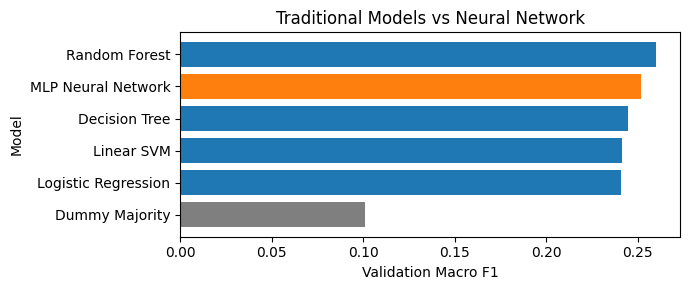

In [5]:
# Plot validation macro F1 to compare baseline, traditional, and neural models.
plot_data = validation_results.sort_values("macro_f1")
colors = plot_data["type"].map({
    "baseline": "tab:gray",
    "traditional": "tab:blue",
    "neural_network": "tab:orange",
})

# Diagram: validation macro F1 bar chart, coloured by model family.
plt.figure(figsize=(7, 3))
plt.barh(plot_data["model"], plot_data["macro_f1"], color=colors)
plt.xlabel("Validation Macro F1")
plt.ylabel("Model")
plt.title("Traditional Models vs Neural Network")
plt.tight_layout()
plt.show()

## 5. Final Test Evaluation

After validation tuning, the chosen version of every model is evaluated on the test set. Detailed classification reports and confusion matrices are shown for the majority baseline, the best traditional validation model, and the MLP neural network.



=== Random Forest ===
              precision    recall  f1-score   support

   declining      0.245     0.235     0.240      1801
      rising      0.255     0.266     0.260      1815
    seasonal      0.254     0.263     0.258      1822
      stable      0.241     0.231     0.236      1774

    accuracy                          0.249      7212
   macro avg      0.249     0.249     0.249      7212
weighted avg      0.249     0.249     0.249      7212



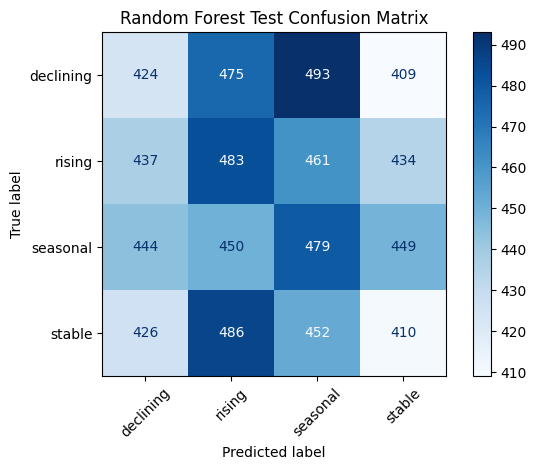


=== MLP Neural Network ===
              precision    recall  f1-score   support

   declining      0.258     0.285     0.271      1801
      rising      0.255     0.277     0.266      1815
    seasonal      0.251     0.232     0.241      1822
      stable      0.264     0.233     0.248      1774

    accuracy                          0.257      7212
   macro avg      0.257     0.257     0.256      7212
weighted avg      0.257     0.257     0.256      7212



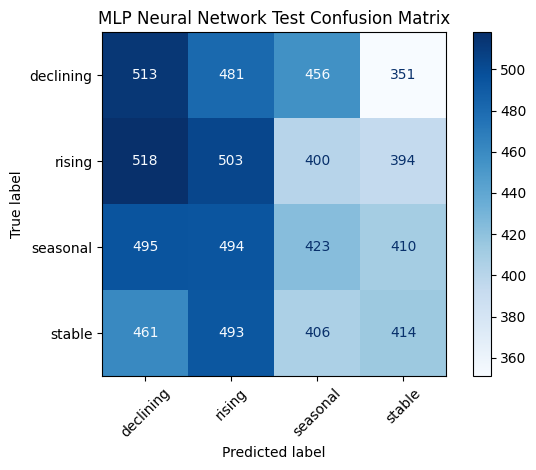


=== Dummy Majority ===
              precision    recall  f1-score   support

   declining      0.000     0.000     0.000      1801
      rising      0.000     0.000     0.000      1815
    seasonal      0.253     1.000     0.403      1822
      stable      0.000     0.000     0.000      1774

    accuracy                          0.253      7212
   macro avg      0.063     0.250     0.101      7212
weighted avg      0.064     0.253     0.102      7212



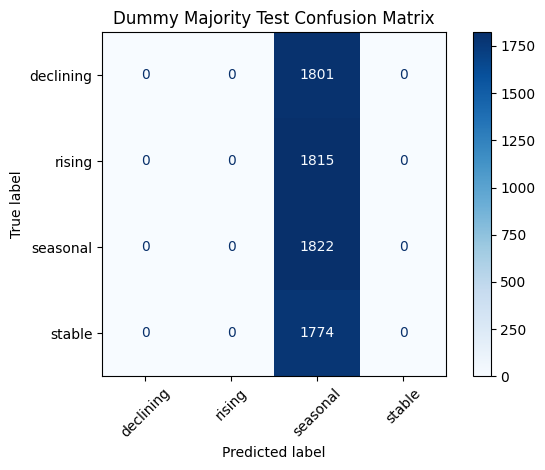

,model,type,chosen_hyperparameters,accuracy,macro_f1
0,MLP Neural Network,neural_network,"alpha=0.001, hidden_layer_sizes=(64, 32)",0.2569,0.2564
1,Linear SVM,traditional,C=1.0,0.2499,0.2494
2,Random Forest,traditional,"min_samples_leaf=5, n_estimators=80",0.2490,0.2487
3,Logistic Regression,traditional,C=0.1,0.2481,0.2480
4,Decision Tree,traditional,"max_depth=12, min_samples_leaf=20",0.2553,0.2439
5,Dummy Majority,baseline,strategy=most_frequent,0.2526,0.1008


In [6]:
# Score all selected models on the held-out test split.
best_traditional = validation_results[validation_results["type"] == "traditional"].iloc[0]["model"]
final_model_names = validation_results["model"].tolist()
# Show detailed reports for the baseline, best traditional model, and neural network.
detailed_model_names = ["Dummy Majority", best_traditional, "MLP Neural Network"]

final_rows = []
for model_name in final_model_names:
    model = trained_models[model_name]
    y_pred = model.predict(X_test)

    final_rows.append({
        "model": model_name,
        "type": model_configs[model_name]["type"],
        "chosen_hyperparameters": format_params(chosen_params[model_name]),
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
    })

    # Confusion matrices are limited to representative models to keep output readable.
    if model_name in detailed_model_names:
        # Output: per-class metrics and confusion matrices for representative models.
        print()
        print("===", model_name, "===")
        print(classification_report(y_test, y_pred, digits=3, zero_division=0))

        ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_pred,
            xticks_rotation=45,
            cmap="Blues",
        )
        plt.title(f"{model_name} Test Confusion Matrix")
        plt.tight_layout()
        plt.show()

final_results = pd.DataFrame(final_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
# Output: final held-out test accuracy and macro F1 for every selected model.
display(final_results.round(4))
